In [161]:
import pandas as pd
import pickle
import math
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# Đọc dữ liệu huấn luyện
File .pkl là file Pickle (1 thư viện có sẵn của Python) hữu ích cho việc lưu trữ dữ liệu và mô hình đã huấn luyện lớn nhờ tốc độ load nhanh của nó. 

Tuy vậy đây là file nhị phân nên khi đọc file phải thêm tham số 'rb' thay vì để trống bởi để trống là mặc định là 'r' với encoder là utf-8 không thể đọc được file nhị phân

In [162]:
with open('data/diabetes_train.pkl','rb') as f:
    diabetes_train = pickle.load(f)
dir(diabetes_train)

['__class__',
 '__class_getitem__',
 '__contains__',
 '__delattr__',
 '__delitem__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getitem__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__ior__',
 '__iter__',
 '__le__',
 '__len__',
 '__lt__',
 '__ne__',
 '__new__',
 '__or__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__reversed__',
 '__ror__',
 '__setattr__',
 '__setitem__',
 '__sizeof__',
 '__str__',
 '__subclasshook__',
 'clear',
 'copy',
 'fromkeys',
 'get',
 'items',
 'keys',
 'pop',
 'popitem',
 'setdefault',
 'update',
 'values']

diabetes_train là kiểu dữ liệu dạng dict và khi ta xem dir có thể thấy 2 cái quan trọng là phương thức keys() trả về keys của dict[] và items() trả về cặp key-value. Ở đây sau khi ta xem keys() và items() thì dữ liệu được tổ chức dưới 2 key và data và target tương ứng với X và y

In [163]:
diabetes_train.keys()

dict_keys(['data', 'target'])

In [164]:
diabetes_train.items()

dict_items([('data', array([[ 0.03807591,  0.05068012,  0.06169621, ..., -0.00259226,
         0.01990842, -0.01764613],
       [-0.00188202, -0.04464164, -0.05147406, ..., -0.03949338,
        -0.06832974, -0.09220405],
       [ 0.08529891,  0.05068012,  0.04445121, ..., -0.00259226,
         0.00286377, -0.02593034],
       ...,
       [ 0.05260606, -0.04464164, -0.00405033, ..., -0.02583997,
         0.03605579,  0.02377494],
       [ 0.01264814, -0.04464164,  0.01535029, ..., -0.00259226,
         0.04506617, -0.06735141],
       [ 0.05987114,  0.05068012,  0.02289497, ..., -0.00259226,
         0.03953988,  0.01963284]], shape=(400, 10))), ('target', array([151.,  75., 141., 206., 135.,  97., 138.,  63., 110., 310., 101.,
        69., 179., 185., 118., 171., 166., 144.,  97., 168.,  68.,  49.,
        68., 245., 184., 202., 137.,  85., 131., 283., 129.,  59., 341.,
        87.,  65., 102., 265., 276., 252.,  90., 100.,  55.,  61.,  92.,
       259.,  53., 190., 142.,  75., 142., 1

In [165]:
X_train = diabetes_train['data']
y_train = diabetes_train['target']

# Huấn luyện mô hình

In [166]:
ls = LinearRegression()
ls.fit(X_train,y_train)
print('[w1,...,wn] = ',ls.coef_)
print('w0 = ',ls.intercept_)

[w1,...,wn] =  [   5.02597344 -238.41461528  521.63399624  299.94110951 -752.12376074
  445.15341214   83.51201877  185.57718337  706.4729074    88.68448421]
w0 =  152.72942545098695


# Đọc dữ liệu test

In [167]:
with open('data/diabetes_test.pkl','rb') as f:
    diabetes_test = pickle.load(f)
diabetes_test.keys()

dict_keys(['data', 'target'])

In [168]:
X_test = diabetes_test['data']
y_test = diabetes_test['target']
y_predict = ls.predict(X_test)
df = pd.DataFrame({'y thực tế': y_test, 'y dự đoán':y_predict,
                   'lệch': abs(y_predict-y_test)})
df.iloc[0:5]

,y thực tế,y dự đoán,lệch
0,175.0,185.393435,10.393435
1,93.0,90.338849,2.661151
2,168.0,152.325453,15.674547
3,275.0,250.866783,24.133217
4,293.0,198.458698,94.541302


In [169]:
rmse = math.sqrt(mean_squared_error(y_test,y_predict))
print("RMSE = ",rmse)

RMSE =  40.850332527287655


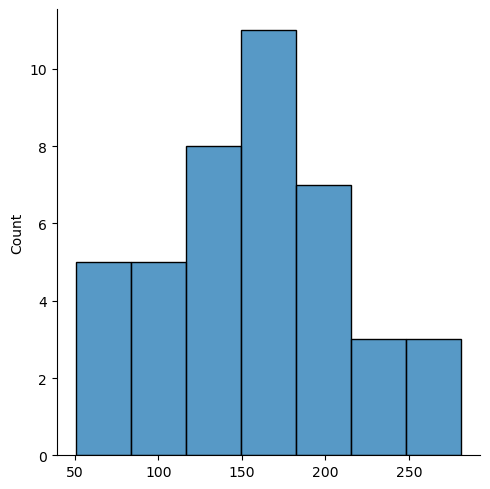

In [170]:
sns.displot(y_predict)